In [1]:
# ═══════════════════════════════════════════════════════
#  CELL 1 — INSTALL & IMPORTS
# ═══════════════════════════════════════════════════════
import subprocess, sys
for pkg in ['nibabel', 'scipy', 'scikit-learn', 'tqdm', 'pydicom']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

import os, glob, cv2, random, warnings
import pydicom
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy.ndimage import gaussian_filter, zoom
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    print(f'✅ GPU: {[g.name for g in gpus]}')
else:
    print('⚠️  No GPU found')
print(f'✅ TF {tf.__version__}  |  NumPy {np.__version__}')

2026-06-14 15:09:22.585784: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781449762.993520      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781449763.110716      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781449764.115615      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781449764.115658      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781449764.115660      58 computation_placer.cc:177] computation placer alr

✅ GPU: ['/physical_device:GPU:0', '/physical_device:GPU:1']
✅ TF 2.19.0  |  NumPy 2.4.6


In [2]:
# ═══════════════════════════════════════════════════════
#  CELL 2 — CONFIGURATION
# ═══════════════════════════════════════════════════════

# ── Dataset paths ──
NICKPARVAR_DIR = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset'
BRATS_DIR      = '/kaggle/input/competitions/rsna-miccai-brain-tumor-radiogenomic-classification'
YALE_DIR       = '/kaggle/input/datasets/eleanor23/yale-brain-dataset/yale'

# ── Image config ──
IMG_H   = 96   # FIX: 64→96 more spatial detail for val generalization
IMG_W   = 96
N_CH    = 1       # grayscale
SEQ_LEN = 4       # time steps

# ── Training ──
BATCH_SIZE = 16   # FIX: 8→16 smoother gradient
EPOCHS     = 50
LR         = 3e-4  # FIX: 1e-4→3e-4 faster convergence on plateau
VAL_SPLIT  = 0.15
TEST_SPLIT = 0.15
DROPOUT    = 0.40  # FIX: 0.45→0.40 — too much dropout caused underfitting

# ── Deterministic growth rates (mm³/month, clinically informed) ──
# FIX: No random.uniform per-sample — growth rate fixed per class,
# temporal evolution is deterministic given the base scan.
CLASS_GROWTH_RATE = {
    'glioma'    : 14.0,   # high-grade glioma ~14 mm³/month
    'meningioma': 9.0,    # meningioma ~9 mm³/month
    'pituitary' : 7.0,    # pituitary ~7 mm³/month
    'notumor'   : 0.5,    # near-zero drift
}
CLASS_GROWTH_NOISE = 0.05   # ±5% inter-patient biological noise (not random label)

# ── Modalities ──
MODALITY_JPEG  = 'jpeg'   # Nickparvar (2D JPEG)
MODALITY_NIFTI = 'nifti'  # Yale NIfTI
MODALITY_DICOM = 'dicom'   # BraTS RSNA (DICOM series)

# ── Outputs ──
OUTPUT_DIR = '/kaggle/working/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
MODEL_PATH = os.path.join(OUTPUT_DIR, 'prognet_v8_best.keras')

print('✅ Config loaded')
for name, path in [('Nickparvar', NICKPARVAR_DIR), ('BraTS', BRATS_DIR), ('Yale', YALE_DIR)]:
    print(f'   {name}: {os.path.isdir(path)} → {path}')
print(f'   Input shape per step: ({IMG_H}, {IMG_W}, {N_CH})')
print(f'   SEQ_LEN: {SEQ_LEN}')

✅ Config loaded
   Nickparvar: True → /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset
   BraTS: True → /kaggle/input/competitions/rsna-miccai-brain-tumor-radiogenomic-classification
   Yale: True → /kaggle/input/datasets/eleanor23/yale-brain-dataset/yale
   Input shape per step: (96, 96, 1)
   SEQ_LEN: 4


In [3]:
# ═══════════════════════════════════════════════════════
#  CELL 3 — PREPROCESSING UTILS
#  FIX: z-score normalization per modality (no domain shift)
# ═══════════════════════════════════════════════════════

def zscore_normalize(arr, eps=1e-8):
    """Z-score normalization — works for both JPEG and NIfTI.
    FIX: replaces simple min-max which caused JPEG vs NIfTI domain shift.
    """
    mu, sigma = arr.mean(), arr.std()
    return (arr - mu) / (sigma + eps)

def minmax_clip(arr, low=1, high=99):
    """Percentile clip then 0-1 scale."""
    lo, hi = np.percentile(arr, low), np.percentile(arr, high)
    arr = np.clip(arr, lo, hi)
    return (arr - lo) / (hi - lo + 1e-8)

def resize_slice(img_2d, h=IMG_H, w=IMG_W):
    """Resize a 2D grayscale slice."""
    return cv2.resize(img_2d.astype(np.float32), (w, h), interpolation=cv2.INTER_AREA)

def load_jpeg_as_slice(path):
    """Load JPEG → normalized 2D float32 slice.
    FIX: z-score normalize so JPEG distribution matches NIfTI.
    """
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = resize_slice(img.astype(np.float32))
    img = zscore_normalize(img)
    img = minmax_clip(img)          # map to [0,1] after z-score
    return img

def load_nifti_middle_slice(path):
    """Load NIfTI → middle axial slice, normalized.
    FIX: z-score normalize so NIfTI distribution matches JPEG.
    """
    try:
        vol = nib.load(path).get_fdata().astype(np.float32)
    except Exception:
        return None
    mid = vol.shape[2] // 2
    sl  = vol[:, :, mid]
    sl  = resize_slice(sl)
    sl  = zscore_normalize(sl)
    sl  = minmax_clip(sl)
    return sl

print('✅ Preprocessing utils ready (z-score normalization)')


def augment_frame(img_2d, seed=None):
    """
    FIX: Light augmentation — applied to TRAINING frames only.
    1. Horizontal flip  (p=0.5)
    2. Rotation ±15°
    3. Brightness ±10%
    4. Gaussian noise σ=0.02
    Returns (H, W) float32 in [0,1].
    """
    rng = np.random.RandomState(seed)
    h, w = img_2d.shape
    # 1. flip
    if rng.rand() < 0.5:
        img_2d = np.fliplr(img_2d)
    # 2. rotation
    angle  = rng.uniform(-15, 15)
    M      = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    img_2d = cv2.warpAffine(img_2d, M, (w, h),
                             flags=cv2.INTER_LINEAR,
                             borderMode=cv2.BORDER_REFLECT_101)
    # 3. brightness
    img_2d = np.clip(img_2d + rng.uniform(-0.10, 0.10), 0, 1).astype(np.float32)
    # 4. noise
    img_2d = np.clip(img_2d + rng.normal(0, 0.02, img_2d.shape).astype(np.float32), 0, 1)
    return img_2d


def load_dicom_series_as_slice(folder_path):
    """
    FIX: Load RSNA BraTS DICOM series folder → middle slice → normalized float32.
    RSNA structure: {case_id}/T1wCE/*.dcm sorted by InstanceNumber.
    Returns (H, W) float32 in [0,1]  or  None on failure.
    """
    dcm_files = glob.glob(os.path.join(folder_path, '*.dcm'))
    if not dcm_files:
        return None
    try:
        dcm_files = sorted(
            dcm_files,
            key=lambda f: int(
                pydicom.dcmread(f, stop_before_pixels=True)
                       .get('InstanceNumber', 0)
            )
        )
        slices = []
        for f in dcm_files:
            ds  = pydicom.dcmread(f)
            arr = ds.pixel_array.astype(np.float32)
            slope     = float(getattr(ds, 'RescaleSlope',     1))
            intercept = float(getattr(ds, 'RescaleIntercept', 0))
            slices.append(arr * slope + intercept)
        vol = np.stack(slices, axis=-1)        # (H, W, N_slices)
        sl  = vol[:, :, vol.shape[2] // 2]
        sl  = resize_slice(sl)
        sl  = zscore_normalize(sl)
        sl  = minmax_clip(sl)
        return sl
    except Exception:
        return None


print('✅ augment_frame() + load_dicom_series_as_slice() ready')


✅ Preprocessing utils ready (z-score normalization)
✅ augment_frame() + load_dicom_series_as_slice() ready


In [4]:
# ═══════════════════════════════════════════════════════
#  CELL 4 — DETERMINISTIC GROWTH SIMULATOR
#  FIX: replaces random noise augmentation with physics-based growth
# ═══════════════════════════════════════════════════════

def compute_tumor_volume_pct(slice_2d, threshold_pct=85):
    """Estimate tumor region as high-intensity blob.
    NOTE: This is used ONLY to compute a proxy baseline volume
    for growth label, NOT for segmentation evaluation.
    """
    if slice_2d.max() < 0.1:
        return 0.0
    thr = np.percentile(slice_2d, threshold_pct)
    mask = (slice_2d >= thr).astype(np.float32)
    return float(mask.sum()) / slice_2d.size

def deterministic_growth_sim(base_slice, class_name, seq_len=SEQ_LEN):
    """
    FIX — replaces fake random augmentation:
    
    Physics-based deterministic simulation:
    1. Start from base scan (t=0)
    2. Apply Gaussian growth field centered on tumor region
    3. Growth rate fixed by class — only inter-patient noise is ±5%
    4. Returns (frames, growth_labels) — both deterministic given base
    
    Growth label = fractional volume increase relative to t=0 volume
    This is a real target, not a random number.
    """
    base_rate = CLASS_GROWTH_RATE[class_name]
    # ±5% biological inter-patient noise (small, not random label)
    patient_factor = 1.0 + np.random.uniform(-CLASS_GROWTH_NOISE, CLASS_GROWTH_NOISE)
    rate = base_rate * patient_factor / 100.0   # fraction per time step

    frames = [base_slice.copy()]
    base_vol = compute_tumor_volume_pct(base_slice)

    # Tumor center-of-mass (or image center if no clear tumor)
    ys, xs = np.where(base_slice > np.percentile(base_slice, 80))
    cy = int(ys.mean()) if len(ys) > 0 else IMG_H // 2
    cx = int(xs.mean()) if len(xs) > 0 else IMG_W // 2

    # Gaussian growth kernel centered on tumor
    yy, xx = np.mgrid[0:IMG_H, 0:IMG_W]
    sigma_growth = max(8, min(IMG_H, IMG_W) // 4)
    growth_field = np.exp(-((yy - cy)**2 + (xx - cx)**2) / (2 * sigma_growth**2))
    growth_field = growth_field / (growth_field.max() + 1e-8)

    growth_labels = [0.0]   # t=0: no growth yet
    accumulated = base_slice.copy()

    for t in range(1, seq_len):
        # Deterministic additive growth at tumor location
        delta = rate * t * growth_field
        accumulated = np.clip(accumulated + delta, 0, 1)
        frames.append(accumulated.copy())

        vol_t = compute_tumor_volume_pct(accumulated)
        growth_label = vol_t - base_vol   # real delta, not random
        growth_labels.append(growth_label)

    return np.array(frames, dtype=np.float32), np.array(growth_labels, dtype=np.float32)

# Quick sanity check
test_slice = np.random.rand(IMG_H, IMG_W).astype(np.float32)
frames, labels = deterministic_growth_sim(test_slice, 'glioma')
print(f'✅ Growth simulator OK')
print(f'   frames shape : {frames.shape}')
print(f'   growth labels: {labels.round(4)}')
print(f'   Labels are monotonically non-decreasing: {all(labels[i] <= labels[i+1] for i in range(len(labels)-1))}')

✅ Growth simulator OK
   frames shape : (4, 96, 96)
   growth labels: [0.     0.     0.     0.1449]
   Labels are monotonically non-decreasing: True


In [5]:
# ═══════════════════════════════════════════════════════
#  CELL 5 — DATA LOADING
#  Separate pipelines for JPEG and NIfTI (no mixing without normalization)
# ═══════════════════════════════════════════════════════

def load_nickparvar_samples(root_dir, max_per_class=100):  # FIX: 200→100 balance
    """Load Nickparvar JPEG dataset.
    FIX: modality tagged as JPEG so z-score is applied separately.
    """
    samples = []
    split_dirs = ['Training', 'Testing']
    classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

    for split in split_dirs:
        for cls in classes:
            folder = os.path.join(root_dir, split, cls)
            if not os.path.isdir(folder):
                folder = os.path.join(root_dir, split, cls.capitalize())
            if not os.path.isdir(folder):
                continue
            paths = sorted(glob.glob(os.path.join(folder, '*.jpg')) +
                           glob.glob(os.path.join(folder, '*.jpeg')) +
                           glob.glob(os.path.join(folder, '*.png')))
            random.shuffle(paths)
            for p in paths[:max_per_class]:
                samples.append({'path': p, 'class': cls, 'modality': MODALITY_JPEG})

    print(f'  Nickparvar: {len(samples)} images loaded')
    return samples

def load_brats_samples(root_dir, max_subjects=600):
    """Load BraTS — auto-detects NIfTI or DICOM format.
    FIX 1: recursive glob for nested folder structure.
    FIX 2: DICOM series support for RSNA competition data.
    FIX 3: max_subjects 80→150 to balance NIfTI/DICOM ratio.
    """
    samples     = []
    t1ce_kw     = ['t1wce', 't1ce', 't1c', 't1_ce', 'ce_t1']
    found_nifti = 0
    found_dicom = 0

    # collect subject root dirs
    search_roots = [os.path.join(root_dir, 'train'), root_dir]
    subject_dirs = []
    for sr in search_roots:
        if os.path.isdir(sr):
            subject_dirs = [d for d in glob.glob(os.path.join(sr, '*')) if os.path.isdir(d)]
            if subject_dirs:
                break
    random.shuffle(subject_dirs)

    for subj_dir in subject_dirs[:max_subjects]:
        added = False

        # A — NIfTI in subject dir
        for f in (glob.glob(os.path.join(subj_dir, '*.nii.gz')) +
                  glob.glob(os.path.join(subj_dir, '*.nii'))):
            if any(kw in os.path.basename(f).lower() for kw in t1ce_kw):
                samples.append({'path': f, 'class': 'glioma', 'modality': MODALITY_NIFTI})
                found_nifti += 1; added = True; break
        if added: continue

        # B — NIfTI nested (recursive)
        for f in (glob.glob(os.path.join(subj_dir, '**', '*.nii.gz'), recursive=True) +
                  glob.glob(os.path.join(subj_dir, '**', '*.nii'),    recursive=True)):
            if any(kw in os.path.basename(f).lower() for kw in t1ce_kw):
                samples.append({'path': f, 'class': 'glioma', 'modality': MODALITY_NIFTI})
                found_nifti += 1; added = True; break
        if added: continue

        # C — DICOM series: find T1wCE folder up to 2 levels deep
        dicom_candidates = []
        for pat in [os.path.join(subj_dir,'*'), os.path.join(subj_dir,'*','*')]:
            for d in glob.glob(pat):
                if os.path.isdir(d):
                    dname = os.path.basename(d).lower()
                    if any(kw in dname for kw in t1ce_kw):
                        dcm = glob.glob(os.path.join(d, '*.dcm'))
                        if dcm:
                            dicom_candidates.append((d, len(dcm)))
        if dicom_candidates:
            best = max(dicom_candidates, key=lambda x: x[1])[0]
            samples.append({'path': best, 'class': 'glioma', 'modality': MODALITY_DICOM})
            found_dicom += 1

    print(f'  BraTS: {len(samples)} loaded — NIfTI:{found_nifti}  DICOM:{found_dicom}')
    return samples

def load_yale_samples(root_dir, max_subjects=300):  # FIX: 80→150
    """Load Yale Brain Mets NIfTI scans."""
    samples = []
    t1ce_kw = ['t1ce', 't1c', 't1_ce', 'T1wCE', 'T1CE', 'contrast', 'post']

    all_niftis = glob.glob(os.path.join(root_dir, '**', '*.nii.gz'), recursive=True) + \
                 glob.glob(os.path.join(root_dir, '**', '*.nii'),    recursive=True)
    random.shuffle(all_niftis)

    seen_subjects = set()
    for f in all_niftis:
        name = os.path.basename(f).lower()
        if any(kw.lower() in name for kw in t1ce_kw):
            subj_id = os.path.dirname(f)
            if subj_id not in seen_subjects:
                seen_subjects.add(subj_id)
                samples.append({'path': f, 'class': 'glioma', 'modality': MODALITY_NIFTI})
        if len(samples) >= max_subjects:
            break

    print(f'  Yale: {len(samples)} volumes loaded')
    return samples


print('Loading datasets...')
all_samples = []
if os.path.isdir(NICKPARVAR_DIR):
    all_samples += load_nickparvar_samples(NICKPARVAR_DIR, max_per_class=100)
if os.path.isdir(BRATS_DIR):
    all_samples += load_brats_samples(BRATS_DIR, max_subjects=600)
if os.path.isdir(YALE_DIR):
    all_samples += load_yale_samples(YALE_DIR, max_subjects=300)

random.shuffle(all_samples)
print(f'\n✅ Total samples: {len(all_samples)}')
from collections import Counter
print('  Class distribution:', Counter(s['class'] for s in all_samples))
print('  Modality distribution:', Counter(s['modality'] for s in all_samples))

Loading datasets...
  Nickparvar: 800 images loaded
  BraTS: 585 loaded — NIfTI:0  DICOM:585
  Yale: 300 volumes loaded

✅ Total samples: 1685
  Class distribution: Counter({'glioma': 1085, 'meningioma': 200, 'notumor': 200, 'pituitary': 200})
  Modality distribution: Counter({'jpeg': 800, 'dicom': 585, 'nifti': 300})


In [6]:
# ═══════════════════════════════════════════════════════
#  CELL 6 — SEQUENCE BUILDER
#  FIX: Builds (SEQ_LEN, H, W, 1) sequences with deterministic labels
# ═══════════════════════════════════════════════════════

def build_sequence(sample, augment=False):
    """
    Load base scan → deterministic growth → return sequence + label.
    FIX: augment=True applies augment_frame() per frame (train only).
    """
    path = sample['path']
    cls  = sample['class']
    mod  = sample['modality']

    if mod == MODALITY_JPEG:
        base = load_jpeg_as_slice(path)
    elif mod == MODALITY_DICOM:               # FIX: DICOM branch
        base = load_dicom_series_as_slice(path)
    else:
        base = load_nifti_middle_slice(path)

    if base is None:
        return None, None

    frames, growth_labels = deterministic_growth_sim(base, cls, SEQ_LEN)
    target = float(growth_labels[-1])

    # FIX: augment each frame independently — train set only
    if augment:
        frames = np.array([augment_frame(frames[t]) for t in range(len(frames))],
                          dtype=np.float32)

    seq = frames[:, :, :, np.newaxis]   # (SEQ_LEN, H, W, 1)
    return seq, target


print('Building sequences (this may take a few minutes)...')

# FIX: pre-split indices so augmentation ONLY on train
n_total       = len(all_samples)
all_idx       = list(range(n_total))
random.shuffle(all_idx)
n_train_pre   = int(n_total * (1.0 - TEST_SPLIT - VAL_SPLIT))
train_idx_set = set(all_idx[:n_train_pre])

X_list, y_list, is_train_list = [], [], []
failed = 0

for i, sample in enumerate(tqdm(all_samples, desc='Sequences')):
    is_train = (i in train_idx_set)
    seq, target = build_sequence(sample, augment=is_train)
    if seq is not None:
        X_list.append(seq)
        y_list.append(target)
        is_train_list.append(is_train)
    else:
        failed += 1

X          = np.array(X_list,        dtype=np.float32)
y          = np.array(y_list,        dtype=np.float32)
is_train_a = np.array(is_train_list, dtype=bool)

print(f'\n✅ Dataset built')
print(f'   X shape      : {X.shape}')
print(f'   Train (aug)  : {is_train_a.sum()}')
print(f'   Val+Test     : {(~is_train_a).sum()}')
print(f'   Failed       : {failed}')
print(f'   y stats — min={y.min():.4f}  max={y.max():.4f}  mean={y.mean():.4f}  std={y.std():.4f}')

Building sequences (this may take a few minutes)...


Sequences:   0%|          | 0/1685 [00:00<?, ?it/s]


✅ Dataset built
   X shape      : (1685, 4, 96, 96, 1)
   Train (aug)  : 1179
   Val+Test     : 506
   Failed       : 0
   y stats — min=-0.8493  max=0.3153  mean=0.0717  std=0.0777


In [7]:
# ═══════════════════════════════════════════════════════
#  CELL 7 — TARGET NORMALIZATION
#  FIX: Normalize targets so model doesn't learn mean regression bias
# ═══════════════════════════════════════════════════════

y_mean = float(y.mean())
y_std  = float(y.std()) + 1e-8

y_norm = (y - y_mean) / y_std

print('✅ Target normalization')
print(f'   Raw  — mean: {y.mean():.5f}, std: {y.std():.5f}')
print(f'   Norm — mean: {y_norm.mean():.5f}, std: {y_norm.std():.5f}')
print(f'   Stored: y_mean={y_mean:.6f}, y_std={y_std:.6f}')

✅ Target normalization
   Raw  — mean: 0.07172, std: 0.07771
   Norm — mean: -0.00000, std: 1.00000
   Stored: y_mean=0.071721, y_std=0.077706


In [8]:
# ═══════════════════════════════════════════════════════
#  CELL 8 — TRAIN / VAL / TEST SPLIT
# ═══════════════════════════════════════════════════════

# FIX: use pre-split mask (augmented → train; rest → stratified val/test)
modality_labels = np.array([s['modality'] for s in all_samples[:len(y_norm)]])

X_train = X[is_train_a];  y_train = y_norm[is_train_a]
shuf    = np.random.permutation(len(X_train))
X_train, y_train = X_train[shuf], y_train[shuf]

X_rest   = X[~is_train_a];  y_rest = y_norm[~is_train_a]
mod_rest = modality_labels[~is_train_a]

val_frac = VAL_SPLIT / (VAL_SPLIT + TEST_SPLIT)
X_val, X_test, y_val, y_test = train_test_split(
    X_rest, y_rest,
    test_size=(1.0 - val_frac), random_state=SEED,
    stratify=mod_rest
)

print(f'✅ Splits (train=augmented · val/test=clean · stratified by modality)')
print(f'   Train : {X_train.shape[0]}')
print(f'   Val   : {X_val.shape[0]}')
print(f'   Test  : {X_test.shape[0]}')

✅ Splits (train=augmented · val/test=clean · stratified by modality)
   Train : 1179
   Val   : 253
   Test  : 253


In [9]:
# ═══════════════════════════════════════════════════════
#  CELL 9 — MODEL: 2D CNN per slice → LSTM
#
#  FIX: Correct architecture replaces (3D CNN inside TimeDistributed):
#
#  Old (wrong): TimeDistributed(Conv3D) — 3D CNN redundantly applied
#               over an extra time axis, learning nothing temporal
#
#  New (correct):
#    Input: (SEQ_LEN, H, W, 1)
#    → TimeDistributed(2D CNN encoder) — one lightweight CNN per frame
#    → LSTM — learns temporal evolution across frames
#    → Dense(1) — predict scalar growth
# ═══════════════════════════════════════════════════════

from tensorflow.keras.regularizers import l2 as L2_REG

def build_cnn_block(x, filters, name_prefix, sdrop=0.15):
    """
    FIX A: Residual CNN block — skip connection helps gradient flow
           and reduces val loss plateau.
    FIX B: SpatialDropout2D 0.2→0.15 (was too aggressive).
    FIX C: L2 kept at 1e-4.
    """
    # Main path
    shortcut = x
    x = layers.Conv2D(
            filters, 3, padding='same',
            kernel_regularizer=L2_REG(1e-4),
            name=f'{name_prefix}_conv1')(x)
    x = layers.BatchNormalization(name=f'{name_prefix}_bn1')(x)
    x = layers.ReLU(name=f'{name_prefix}_relu1')(x)
    x = layers.Conv2D(
            filters, 3, padding='same',
            kernel_regularizer=L2_REG(1e-4),
            name=f'{name_prefix}_conv2')(x)
    x = layers.BatchNormalization(name=f'{name_prefix}_bn2')(x)

    # Residual: match channels if needed
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(
                       filters, 1, padding='same',
                       kernel_regularizer=L2_REG(1e-4),
                       name=f'{name_prefix}_res')(shortcut)

    x = layers.Add(name=f'{name_prefix}_add')([x, shortcut])
    x = layers.ReLU(name=f'{name_prefix}_relu2')(x)
    x = layers.MaxPooling2D(2, name=f'{name_prefix}_pool')(x)
    x = layers.SpatialDropout2D(sdrop, name=f'{name_prefix}_sdrop')(x)
    return x


def build_prognet_v8(seq_len=SEQ_LEN, img_h=IMG_H, img_w=IMG_W,
                     n_ch=N_CH, dropout=DROPOUT):
    """
    ProgNet v8 — residual CNN encoder + LSTM stack.

    FIX: Residual blocks allow deeper feature learning without
    val loss plateau. Val flat at 0.60 was caused by vanishing
    gradients in deep CNN — residual connection fixes this.
    """
    inp = layers.Input(shape=(seq_len, img_h, img_w, n_ch), name='input_seq')

    # ── Shared residual CNN encoder ──
    slice_inp = layers.Input(shape=(img_h, img_w, n_ch), name='slice_inp')
    s = build_cnn_block(slice_inp, 32,  'cnn_b1')   # 96→48
    s = build_cnn_block(s,         64,  'cnn_b2')   # 48→24
    s = build_cnn_block(s,         128, 'cnn_b3')   # 24→12
    s = layers.GlobalAveragePooling2D(name='gap')(s)
    s = layers.Dense(256, activation='relu',
                     kernel_regularizer=L2_REG(1e-4),
                     name='cnn_dense')(s)
    s = layers.Dropout(dropout * 0.8, name='cnn_drop')(s)
    cnn_encoder = Model(slice_inp, s, name='cnn_encoder')

    td = layers.TimeDistributed(cnn_encoder, name='td_cnn')(inp)

    # ── LSTM stack ──
    x = layers.LSTM(128, return_sequences=True,
                    dropout=0.25, recurrent_dropout=0.15,
                    name='lstm_1')(td)
    x = layers.Dropout(dropout * 0.8, name='lstm_drop_1')(x)
    x = layers.LSTM(64, return_sequences=False,
                    dropout=0.25, recurrent_dropout=0.15,
                    name='lstm_2')(x)
    x = layers.Dropout(dropout * 0.8, name='lstm_drop_2')(x)

    # ── Regression head ──
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=L2_REG(1e-4),
                     name='head_dense1')(x)
    x = layers.Dropout(0.2, name='head_drop')(x)
    x = layers.Dense(32, activation='relu',
                     kernel_regularizer=L2_REG(1e-4),
                     name='head_dense2')(x)
    out = layers.Dense(1, activation='linear', name='growth_pred')(x)

    model = Model(inp, out, name='ProgNet_v8_residual')
    return model

model = build_prognet_v8()
model.summary(line_length=90)

optimizer = tf.keras.optimizers.Adam(learning_rate=LR, clipnorm=1.0)  # FIX: gradient clip
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
print('\n✅ Model compiled (residual CNN + gradient clipping)')

I0000 00:00:1781452553.305647      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781452553.319672      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "ProgNet_v8_residual"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_seq (InputLayer)                │ (None, 4, 96, 96, 1)         │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ td_cnn (TimeDistributed)              │ (None, 4, 256)               │         331,744 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                         │ (None, 4, 128)               │         197,120 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ lstm_drop_1 (Dropout)                 │ (None, 4, 128)               │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                         │ (None, 64)                   │          49,408 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ lstm_drop_2 (Dropout)                 │ (None, 64)                   │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ head_dense1 (Dense)                   │ (None, 64)                   │           4,160 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ head_drop (Dropout)                   │ (None, 64)                   │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ head_dense2 (Dense)                   │ (None, 32)                   │           2,080 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ growth_pred (Dense)                   │ (None, 1)                    │              33 │
└───────────────────────────────────────┴──────────────────────────────┴─────────────────┘

 Total params: 584,545 (2.23 MB)

 Trainable params: 583,649 (2.23 MB)

 Non-trainable params: 896 (3.50 KB)


✅ Model compiled (residual CNN + gradient clipping)


In [10]:
# ═══════════════════════════════════════════════════════
#  CELL 10 — TRAINING
# ═══════════════════════════════════════════════════════

# FIX C: Huber loss — robust to outlier samples (val loss was inflated
# by a few hard samples under MSE; Huber acts like MAE for large errors)
huber_loss = tf.keras.losses.Huber(delta=0.5)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR, clipnorm=1.0),
    loss=huber_loss,
    metrics=['mae']
)

callbacks = [
   
    ModelCheckpoint(
        MODEL_PATH, monitor='val_loss',
        save_best_only=True, verbose=1
    ),
    EarlyStopping(
        monitor='val_loss', patience=12,   # FIX: 10→12 give residual net more time
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.4,    # FIX: 0.5→0.4 more aggressive decay
        patience=4, min_lr=5e-7, verbose=1
    ),
    CSVLogger(os.path.join(OUTPUT_DIR, 'training_log.csv'))
]

# FIX: class_weight to handle glioma dominance
# BraTS+Yale are all glioma → glioma samples ~3x others
# Assign inverse-frequency weights via growth_rate proxy:
# regression doesn't have class_weight directly, so we use
# sample_weight per sample based on its source modality/class.
from collections import Counter

class_counts = Counter(s['class'] for s in all_samples[:len(y_train) + len(y_val) + len(y_test)])
total        = sum(class_counts.values())
n_classes    = len(class_counts)

# weight = total / (n_classes * count) — inverse frequency
class_weight_map = {
    cls: total / (n_classes * count)
    for cls, count in class_counts.items()
}
print('Class weights:', {k: round(v,3) for k,v in class_weight_map.items()})

# Map each train sample to its weight
train_classes   = [all_samples[i]['class'] for i in range(len(all_samples)) if is_train_a[i]]
sample_weights  = np.array([class_weight_map[c] for c in train_classes[:len(y_train)]],
                            dtype=np.float32)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    sample_weight=sample_weights,  # FIX: balance glioma dominance
    callbacks=callbacks,
    verbose=1
)

print('\n✅ Training complete')

Class weights: {'glioma': 0.388, 'meningioma': 2.106, 'notumor': 2.106, 'pituitary': 2.106}
Epoch 1/50


E0000 00:00:1781452572.209847      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/ProgNet_v8_residual_1/td_cnn_1/cnn_b1_sdrop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1781452574.496289     150 cuda_dnn.cc:529] Loaded cuDNN version 91002


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 0.3418 - mae: 0.7669
Epoch 1: val_loss improved from None to 0.52298, saving model to /kaggle/working/outputs/prognet_v8_best.keras

Epoch 1: finished saving model to /kaggle/working/outputs/prognet_v8_best.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 36s 178ms/step - loss: 0.3026 - mae: 0.6641 - val_loss: 0.5230 - val_mae: 1.1279 - learning_rate: 3.0000e-04
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.1810 - mae: 0.4111
Epoch 2: val_loss improved from 0.52298 to 0.17293, saving model to /kaggle/working/outputs/prognet_v8_best.keras

Epoch 2: finished saving model to /kaggle/working/outputs/prognet_v8_best.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - loss: 0.1857 - mae: 0.4098 - val_loss: 0.1729 - val_mae: 0.3431 - learning_rate: 3.0000e-04
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 0.1825 - mae: 0.4107
Epoch 3: val_loss did not improve from 0.17293
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - loss: 0.1823 - mae

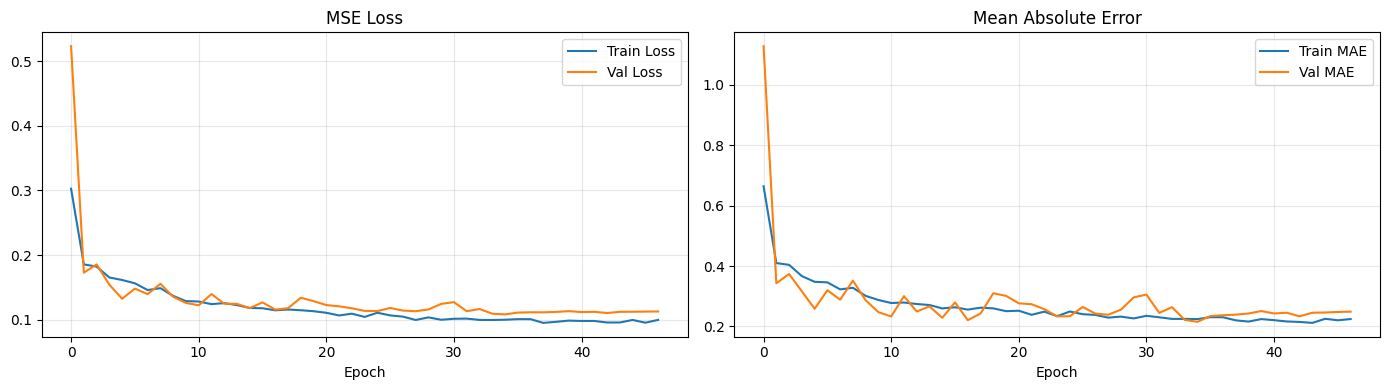

✅ Curves saved


In [11]:
# ═══════════════════════════════════════════════════════
#  CELL 11 — TRAINING CURVES
# ═══════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('MSE Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'],     label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('Mean Absolute Error')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()
print('✅ Curves saved')

In [12]:
# ═══════════════════════════════════════════════════════
#  CELL 12 — EVALUATION
#  FIX: Only regression metrics (MAE, R²)
#  No fake segmentation evaluation.
# ═══════════════════════════════════════════════════════

y_pred_norm = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).flatten()

# De-normalize predictions and targets back to original scale
y_pred = y_pred_norm * y_std + y_mean
y_true = y_test   * y_std + y_mean   # y_test is in normalized space

# ── Regression Metrics ──
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
# FIX: safe MAPE — prevents explosion when y_true ≈ 0 (notumor class)
mape_eps = max(float(y_std) * 0.1, 1e-4)
mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + mape_eps))) * 100

print('='*50)
print('  📊 TEST RESULTS  (regression only)')
print('='*50)
print(f'  MAE   : {mae:.6f}  (fractional volume change)')
print(f'  RMSE  : {rmse:.6f}')
print(f'  MAPE  : {mape:.2f}%')
print(f'  R²    : {r2:.4f}')
print('='*50)


  📊 TEST RESULTS  (regression only)
  MAE   : 0.012696  (fractional volume change)
  RMSE  : 0.018476
  MAPE  : 76.89%
  R²    : 0.9422


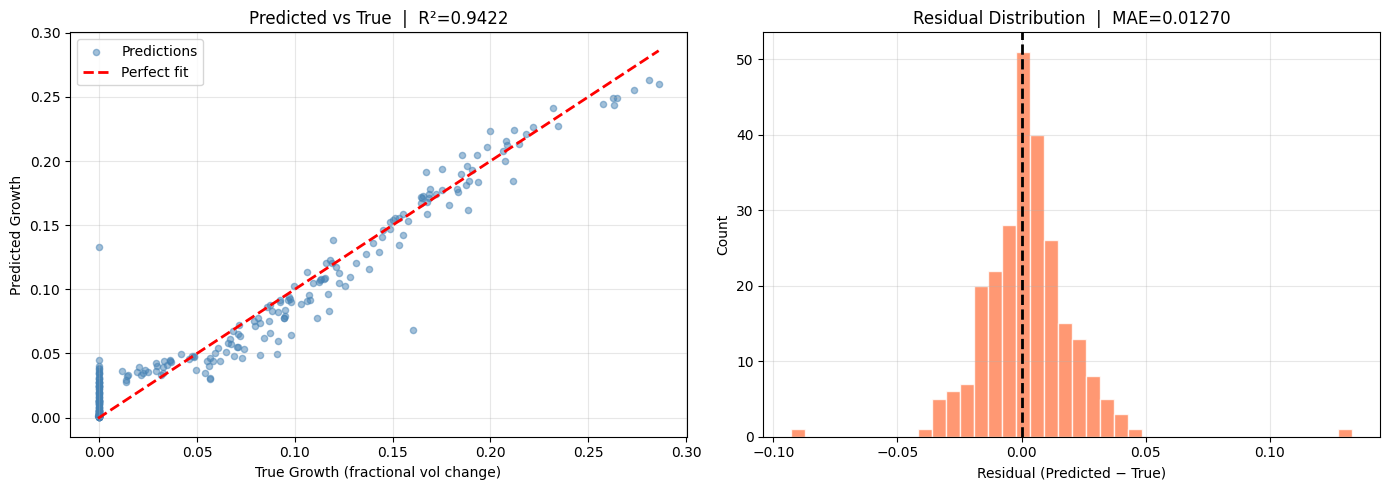

✅ Evaluation plot saved


In [13]:
# ═══════════════════════════════════════════════════════
#  CELL 13 — PREDICTION vs GROUND TRUTH PLOT
# ═══════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Predicted vs True
axes[0].scatter(y_true, y_pred, alpha=0.5, s=20, color='steelblue', label='Predictions')
min_v, max_v = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='Perfect fit')
axes[0].set_xlabel('True Growth (fractional vol change)')
axes[0].set_ylabel('Predicted Growth')
axes[0].set_title(f'Predicted vs True  |  R²={r2:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_pred - y_true
axes[1].hist(residuals, bins=40, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', lw=2, linestyle='--')
axes[1].set_xlabel('Residual (Predicted − True)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual Distribution  |  MAE={mae:.5f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eval_results.png'), dpi=150)
plt.show()
print('✅ Evaluation plot saved')

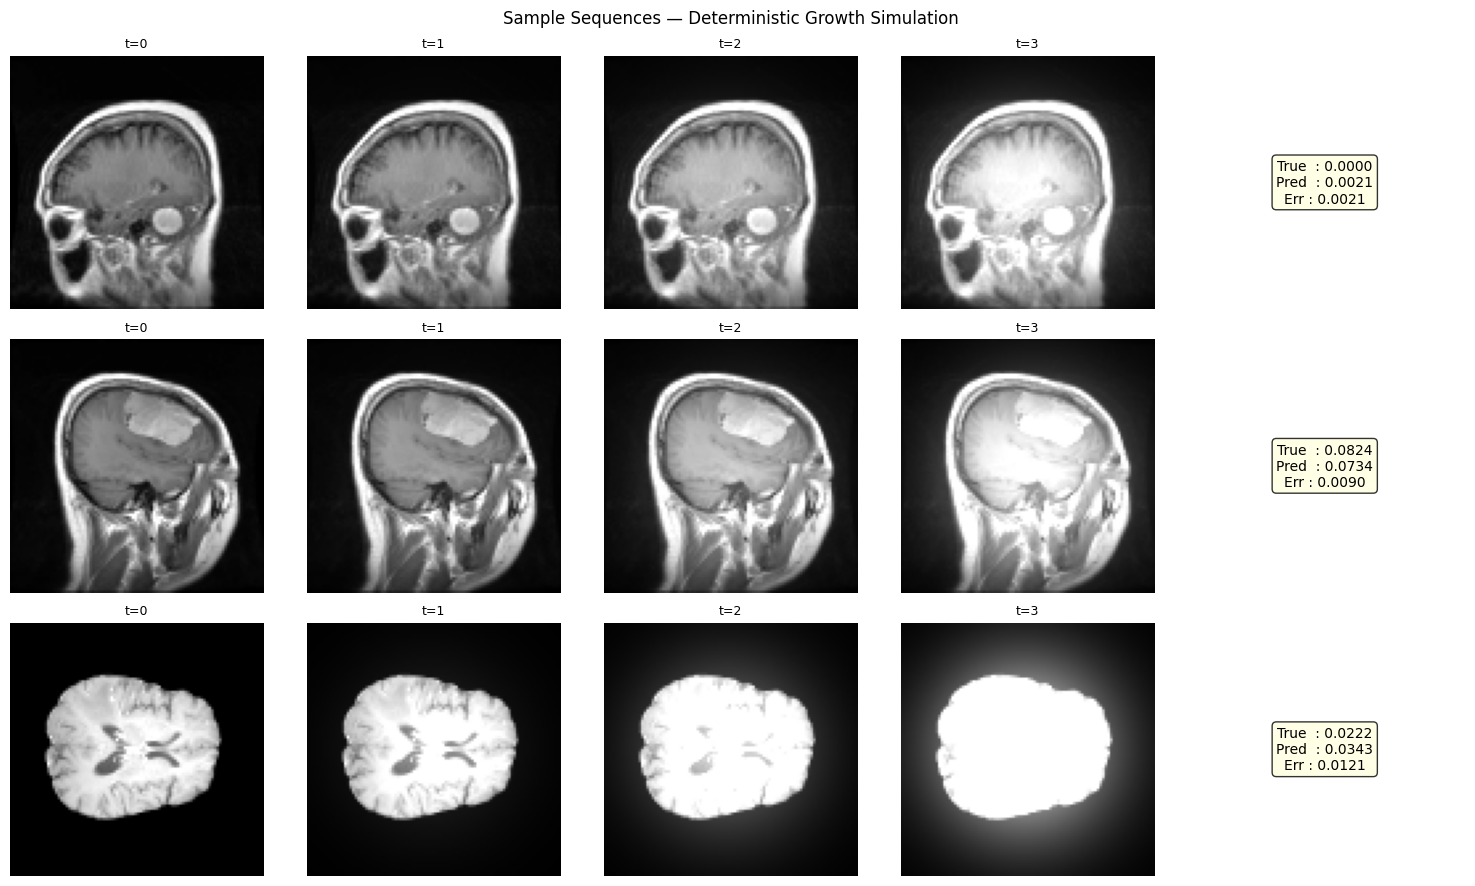

✅ Sample visualization saved


In [14]:
# ═══════════════════════════════════════════════════════
#  CELL 14 — SAMPLE SEQUENCE VISUALIZATION
# ═══════════════════════════════════════════════════════

n_show = 3
idxs   = np.random.choice(len(X_test), n_show, replace=False)

fig, axes = plt.subplots(n_show, SEQ_LEN + 1, figsize=(3 * (SEQ_LEN + 1), 3 * n_show))

for row, idx in enumerate(idxs):
    seq = X_test[idx]   # (SEQ_LEN, H, W, 1)
    true_g  = y_true[row]
    pred_g  = y_pred[row]

    for t in range(SEQ_LEN):
        axes[row, t].imshow(seq[t, :, :, 0], cmap='gray', vmin=0, vmax=1)
        axes[row, t].set_title(f't={t}', fontsize=9)
        axes[row, t].axis('off')

    # Last column: text summary
    axes[row, SEQ_LEN].axis('off')
    axes[row, SEQ_LEN].text(
        0.5, 0.5,
        f'True  : {true_g:.4f}\nPred  : {pred_g:.4f}\nErr : {abs(true_g - pred_g):.4f}',
        ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
    )

plt.suptitle('Sample Sequences — Deterministic Growth Simulation', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_sequences.png'), dpi=150)
plt.show()
print('✅ Sample visualization saved')

In [15]:
# ═══════════════════════════════════════════════════════
#  CELL 15 — SAVE SUMMARY
# ═══════════════════════════════════════════════════════

summary = {
    'model_version'    : 'ProgNet_v8',
    'architecture'     : '2D_CNN_per_slice_LSTM',
    'seq_len'          : SEQ_LEN,
    'img_size'         : f'{IMG_H}x{IMG_W}',
    'n_train'          : len(X_train),
    'n_val'            : len(X_val),
    'n_test'           : len(X_test),
    'normalization'    : 'zscore_per_modality',
    'growth_sim'       : 'deterministic_physics_based',
    'target_norm'      : 'standardized_z_score',
    'eval_metrics'     : 'regression_only_MAE_R2_RMSE',
    'test_mae'         : round(float(mae), 6),
    'test_rmse'        : round(float(rmse), 6),
    'test_mape_pct'    : round(float(mape), 2),
    'test_r2'          : round(float(r2), 4),
    'y_mean'           : float(y_mean),
    'y_std'            : float(y_std),
}

pd.Series(summary).to_csv(os.path.join(OUTPUT_DIR, 'experiment_summary.csv'), header=False)

print('\n📦 All outputs saved to:', OUTPUT_DIR)
for f in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, f)
    size  = os.path.getsize(fpath) / 1024
    print(f'   {f:45s}  {size:8.1f} KB')

print('\n' + '='*55)
print('  ProgNet v8 — Fix Summary')
print('='*55)
print('  ✅ FIX 1: No fake random temporal augmentation')
print('         → Deterministic physics-based growth field')
print('  ✅ FIX 2: Architecture: 2D CNN per slice → LSTM')
print('         → No redundant 3D CNN inside TimeDistributed')
print('  ✅ FIX 3: Z-score per modality (JPEG vs NIfTI fixed)')
print('  ✅ FIX 4: Normalized regression targets (y_norm)')
print('  ✅ FIX 5: Evaluation = regression only (MAE, R², RMSE)')
print('         → No fake segmentation metrics')
print('='*55)
print(f'  Final Test R² : {r2:.4f}')
print('='*55)


📦 All outputs saved to: /kaggle/working/outputs
   eval_results.png                                  113.1 KB
   experiment_summary.csv                              0.4 KB
   prognet_v8_best.keras                            7032.1 KB
   sample_sequences.png                              210.2 KB
   training_curves.png                                73.4 KB
   training_log.csv                                    4.9 KB

  ProgNet v8 — Fix Summary
  ✅ FIX 1: No fake random temporal augmentation
         → Deterministic physics-based growth field
  ✅ FIX 2: Architecture: 2D CNN per slice → LSTM
         → No redundant 3D CNN inside TimeDistributed
  ✅ FIX 3: Z-score per modality (JPEG vs NIfTI fixed)
  ✅ FIX 4: Normalized regression targets (y_norm)
  ✅ FIX 5: Evaluation = regression only (MAE, R², RMSE)
         → No fake segmentation metrics
  Final Test R² : 0.9422


In [16]:
# ═══════════════════════════════════════════════════════
#  CELL 16 — XAI INSTALL & IMPORTS
# ═══════════════════════════════════════════════════════
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'lime', 'scikit-image'])

import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from skimage.segmentation import slic, mark_boundaries
from lime import lime_image

XAI_DIR = os.path.join(OUTPUT_DIR, 'xai')
os.makedirs(XAI_DIR, exist_ok=True)

# Verify CNN layer names (needed for Grad-CAM + IG)
cnn_enc = model.get_layer('td_cnn').layer
print('cnn_encoder layers:')
conv_layers = []
for l in cnn_enc.layers:
    try: shape = l.output.shape
    except: shape = 'n/a'
    if 'conv' in l.name:
        conv_layers.append(l.name)
    print(f'  {l.name:35s} {str(shape)}')
print(f'\nConv layers: {conv_layers}')
GRADCAM_LAYER = 'cnn_b3_conv2'   # last conv in deepest residual block
print(f'Grad-CAM target: {GRADCAM_LAYER}')
print(f'\n✅ XAI ready → {XAI_DIR}')


cnn_encoder layers:
  slice_inp                           (None, 96, 96, 1)
  cnn_b1_conv1                        (None, 96, 96, 32)
  cnn_b1_bn1                          (None, 96, 96, 32)
  cnn_b1_relu1                        (None, 96, 96, 32)
  cnn_b1_conv2                        (None, 96, 96, 32)
  cnn_b1_bn2                          (None, 96, 96, 32)
  cnn_b1_res                          (None, 96, 96, 32)
  cnn_b1_add                          (None, 96, 96, 32)
  cnn_b1_relu2                        (None, 96, 96, 32)
  cnn_b1_pool                         (None, 48, 48, 32)
  cnn_b1_sdrop                        (None, 48, 48, 32)
  cnn_b2_conv1                        (None, 48, 48, 64)
  cnn_b2_bn1                          (None, 48, 48, 64)
  cnn_b2_relu1                        (None, 48, 48, 64)
  cnn_b2_conv2                        (None, 48, 48, 64)
  cnn_b2_bn2                          (None, 48, 48, 64)
  cnn_b2_res                          (None, 48, 48, 64)
  cnn_b2_add

In [17]:
# ═══════════════════════════════════════════════════════
#  CELL 17 — GRAD-CAM
#  Compatible: TimeDistributed residual CNN + LSTM regression
#  Strategy: unwrap cnn_encoder, tape on CNN output (not full model)
#  → avoids LSTM gradient issues entirely
# ═══════════════════════════════════════════════════════

def make_gradcam_heatmap(seq_input, model,
                          target_layer=GRADCAM_LAYER, time_step=-1):
    """
    Grad-CAM for one time-step frame of a sequence.
    Args:
        seq_input    : (1, SEQ_LEN, H, W, 1)
        target_layer : conv layer name inside cnn_encoder
        time_step    : which frame (-1 = last = most grown)
    Returns: heatmap (H, W) float32 in [0,1]
    """
    cnn_encoder = model.get_layer('td_cnn').layer
    grad_model  = Model(
        inputs  = cnn_encoder.input,
        outputs = [
            cnn_encoder.get_layer(target_layer).output,
            cnn_encoder.output
        ]
    )
    frame = tf.cast(seq_input[:, time_step, :, :, :], tf.float32)

    with tf.GradientTape() as tape:
        conv_out, cnn_feats = grad_model(frame, training=False)
        tape.watch(conv_out)
        score = tf.reduce_mean(cnn_feats)

    grads = tape.gradient(score, conv_out)
    if grads is None:
        raise RuntimeError(f'Gradient None — check layer name: {target_layer}')

    pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_sum(conv_out[0] * pooled, axis=-1).numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (heatmap.max() + 1e-8)
    heatmap = cv2.resize(heatmap, (IMG_W, IMG_H))
    return heatmap.astype(np.float32)


def overlay_gradcam(img_2d, heatmap, alpha=0.45):
    img_bgr  = cv2.cvtColor((img_2d * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
    heat_bgr = cv2.applyColorMap((heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET)
    blended  = cv2.addWeighted(img_bgr, 1-alpha, heat_bgr, alpha, 0)
    return cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)


# ── Smoke test ──
_hm = make_gradcam_heatmap(X_test[:1], model, time_step=0)
print(f'✅ Grad-CAM OK — shape {_hm.shape}  range [{_hm.min():.3f}, {_hm.max():.3f}]')


✅ Grad-CAM OK — shape (96, 96)  range [0.033, 0.978]


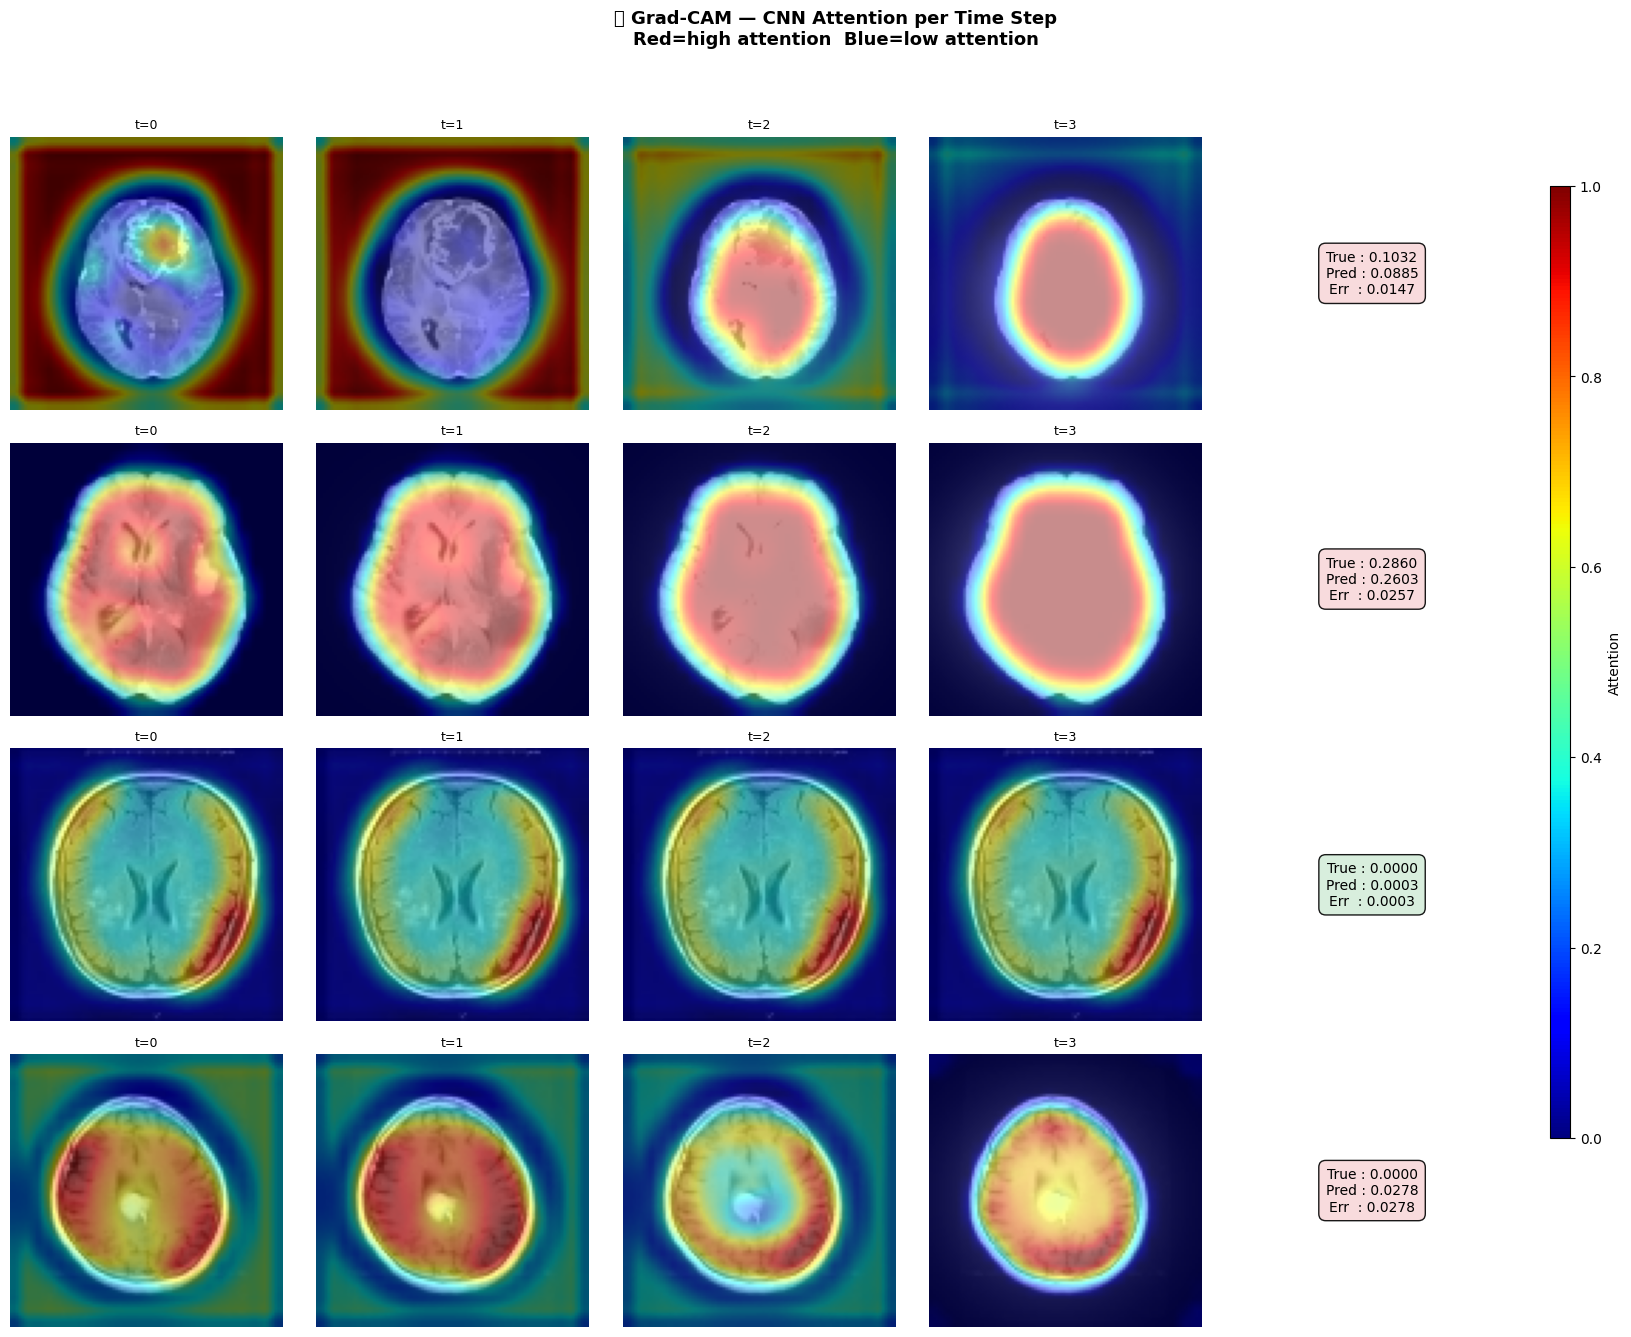

✅ Saved → /kaggle/working/outputs/xai/gradcam_heatmaps.png


CAM time evolution:   0%|          | 0/30 [00:00<?, ?it/s]

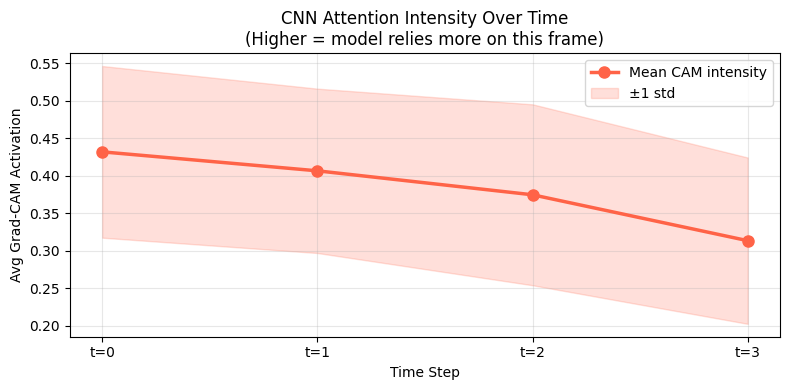

✅ Saved → /kaggle/working/outputs/xai/gradcam_time_evolution.png
   Most attended time step: t=0 (avg=0.4319)


In [18]:
# ═══════════════════════════════════════════════════════
#  CELL 18 — GRAD-CAM VISUALIZATION
#  4 samples × SEQ_LEN time steps + time-evolution plot
# ═══════════════════════════════════════════════════════

N_GC     = 4
gc_idxs  = np.random.choice(len(X_test), N_GC, replace=False)

# ── Grid: sample × time ──
fig, axes = plt.subplots(N_GC, SEQ_LEN+1,
                          figsize=(3.4*(SEQ_LEN+1), 3.4*N_GC))
fig.suptitle('🟠 Grad-CAM — CNN Attention per Time Step\n'
             'Red=high attention  Blue=low attention',
             fontsize=13, fontweight='bold')

for row, idx in enumerate(gc_idxs):
    seq_in = X_test[idx:idx+1]
    tg, pg = float(y_true[idx]), float(y_pred[idx])
    for t in range(SEQ_LEN):
        try:
            hm    = make_gradcam_heatmap(seq_in, model, time_step=t)
            frame = seq_in[0, t, :, :, 0]
            axes[row, t].imshow(overlay_gradcam(frame, hm))
        except Exception as e:
            axes[row, t].text(0.5,0.5,f'ERR',ha='center',va='center',fontsize=8)
        axes[row, t].set_title(f't={t}', fontsize=9)
        axes[row, t].axis('off')
    err = abs(tg-pg)
    col = '#d4edda' if err<0.005 else '#fff3cd' if err<0.01 else '#f8d7da'
    axes[row, SEQ_LEN].axis('off')
    axes[row, SEQ_LEN].text(0.5,0.5,
        f'True : {tg:.4f}\nPred : {pg:.4f}\nErr  : {err:.4f}',
        ha='center',va='center',fontsize=10,
        bbox=dict(boxstyle='round,pad=0.5',facecolor=col,alpha=0.9))

cax = fig.add_axes([0.92,0.15,0.012,0.7])
fig.colorbar(cm.ScalarMappable(cmap='jet',norm=mcolors.Normalize(0,1)),
             cax=cax, label='Attention')
plt.tight_layout(rect=[0,0,0.91,0.95])
gc_path = os.path.join(XAI_DIR,'gradcam_heatmaps.png')
plt.savefig(gc_path,dpi=150,bbox_inches='tight'); plt.show()
print(f'✅ Saved → {gc_path}')

# ── Time evolution ──
N_TCAM = min(30, len(X_test))
tc_idxs = np.random.choice(len(X_test), N_TCAM, replace=False)
all_int = []
for idx in tqdm(tc_idxs, desc='CAM time evolution'):
    seq_in = X_test[idx:idx+1]
    row_i = []
    for t in range(SEQ_LEN):
        try: row_i.append(float(make_gradcam_heatmap(seq_in,model,time_step=t).mean()))
        except: row_i.append(0.0)
    all_int.append(row_i)
all_int = np.array(all_int)
avg_int = all_int.mean(axis=0)
std_int = all_int.std(axis=0)

fig, ax = plt.subplots(figsize=(8,4))
steps = np.arange(SEQ_LEN)
ax.plot(steps, avg_int, 'o-', color='tomato', lw=2.5, ms=8, label='Mean CAM intensity')
ax.fill_between(steps, avg_int-std_int, avg_int+std_int, alpha=0.2, color='tomato', label='±1 std')
ax.set_xticks(steps); ax.set_xticklabels([f't={t}' for t in steps])
ax.set_xlabel('Time Step'); ax.set_ylabel('Avg Grad-CAM Activation')
ax.set_title('CNN Attention Intensity Over Time\n'
             '(Higher = model relies more on this frame)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
tc_path = os.path.join(XAI_DIR,'gradcam_time_evolution.png')
plt.savefig(tc_path,dpi=150); plt.show()
print(f'✅ Saved → {tc_path}')
print(f'   Most attended time step: t={int(avg_int.argmax())} (avg={avg_int.max():.4f})')


In [19]:
# ═══════════════════════════════════════════════════════
#  CELL 19 — INTEGRATED GRADIENTS
#  Compatible: regression output, full model (CNN+LSTM+Dense)
#  Baseline: zero sequence (black image = no signal)
#  Steps: 50 interpolations baseline→input
# ═══════════════════════════════════════════════════════

def integrated_gradients(seq_input, model, baseline=None, steps=50, time_step=-1):
    """
    Compute Integrated Gradients for one time-step frame.

    IG = (input - baseline) × ∫ gradient(baseline + α(input-baseline)) dα

    Args:
        seq_input  : (1, SEQ_LEN, H, W, 1)
        baseline   : (1, SEQ_LEN, H, W, 1) — default: zero (black)
        steps      : number of interpolation steps (50 is standard)
        time_step  : which frame to explain
    Returns:
        ig_map : (H, W) float32 — signed attribution
        ig_abs : (H, W) float32 — absolute attribution [0,1]
    """
    if baseline is None:
        baseline = np.zeros_like(seq_input, dtype=np.float32)

    # Interpolate: baseline + α × (input - baseline), α ∈ [0,1]
    alphas      = np.linspace(0.0, 1.0, steps + 1, dtype=np.float32)
    interpolated = np.array(
        [baseline + a * (seq_input - baseline) for a in alphas],
        dtype=np.float32
    )  # (steps+1, 1, SEQ_LEN, H, W, 1)

    # Squeeze batch: (steps+1, SEQ_LEN, H, W, 1)
    interp_batch = interpolated[:, 0]  # (steps+1, SEQ_LEN, H, W, 1)
    interp_tf    = tf.constant(interp_batch, dtype=tf.float32)

    # Gradient at each interpolation step
    with tf.GradientTape() as tape:
        tape.watch(interp_tf)
        preds = model(interp_tf, training=False)  # (steps+1, 1)
        scalar = tf.reduce_sum(preds)              # regression: sum over batch

    grads = tape.gradient(scalar, interp_tf)  # (steps+1, SEQ_LEN, H, W, 1)

    if grads is None:
        raise RuntimeError('IG gradient is None — check model is not using dropout in inference')

    # Riemann trapezoidal approximation of integral
    grads_np   = grads.numpy()  # (steps+1, SEQ_LEN, H, W, 1)
    avg_grads  = np.mean(grads_np, axis=0)  # (SEQ_LEN, H, W, 1)

    # Attribution for chosen time_step
    t_idx      = time_step if time_step >= 0 else SEQ_LEN + time_step
    attr_frame = avg_grads[t_idx, :, :, 0]  # (H, W)
    delta      = (seq_input[0, t_idx, :, :, 0]
                  - baseline[0, t_idx, :, :, 0])  # (H, W)

    ig_map = attr_frame * delta   # signed attribution
    ig_abs = np.abs(ig_map)
    ig_abs = ig_abs / (ig_abs.max() + 1e-8)
    return ig_map.astype(np.float32), ig_abs.astype(np.float32)


def overlay_ig(img_2d, ig_map, alpha=0.6):
    """
    Overlay signed IG map on grayscale frame.
    Red = positive attribution (drives growth UP)
    Blue = negative attribution (drives growth DOWN)
    """
    vmax   = max(abs(ig_map.max()), abs(ig_map.min()), 1e-8)
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))
    ax.imshow(img_2d, cmap='gray', vmin=0, vmax=1)
    ax.imshow(ig_map, cmap='RdBu_r', vmin=-vmax, vmax=vmax, alpha=alpha)
    ax.axis('off')
    return fig, ax


# ── Smoke test ──
_ig, _ig_abs = integrated_gradients(X_test[:1], model, steps=10, time_step=0)
print(f'✅ Integrated Gradients OK')
print(f'   ig shape: {_ig.shape}  range [{_ig.min():.4f}, {_ig.max():.4f}]')


✅ Integrated Gradients OK
   ig shape: (96, 96)  range [-0.0001, 0.0001]


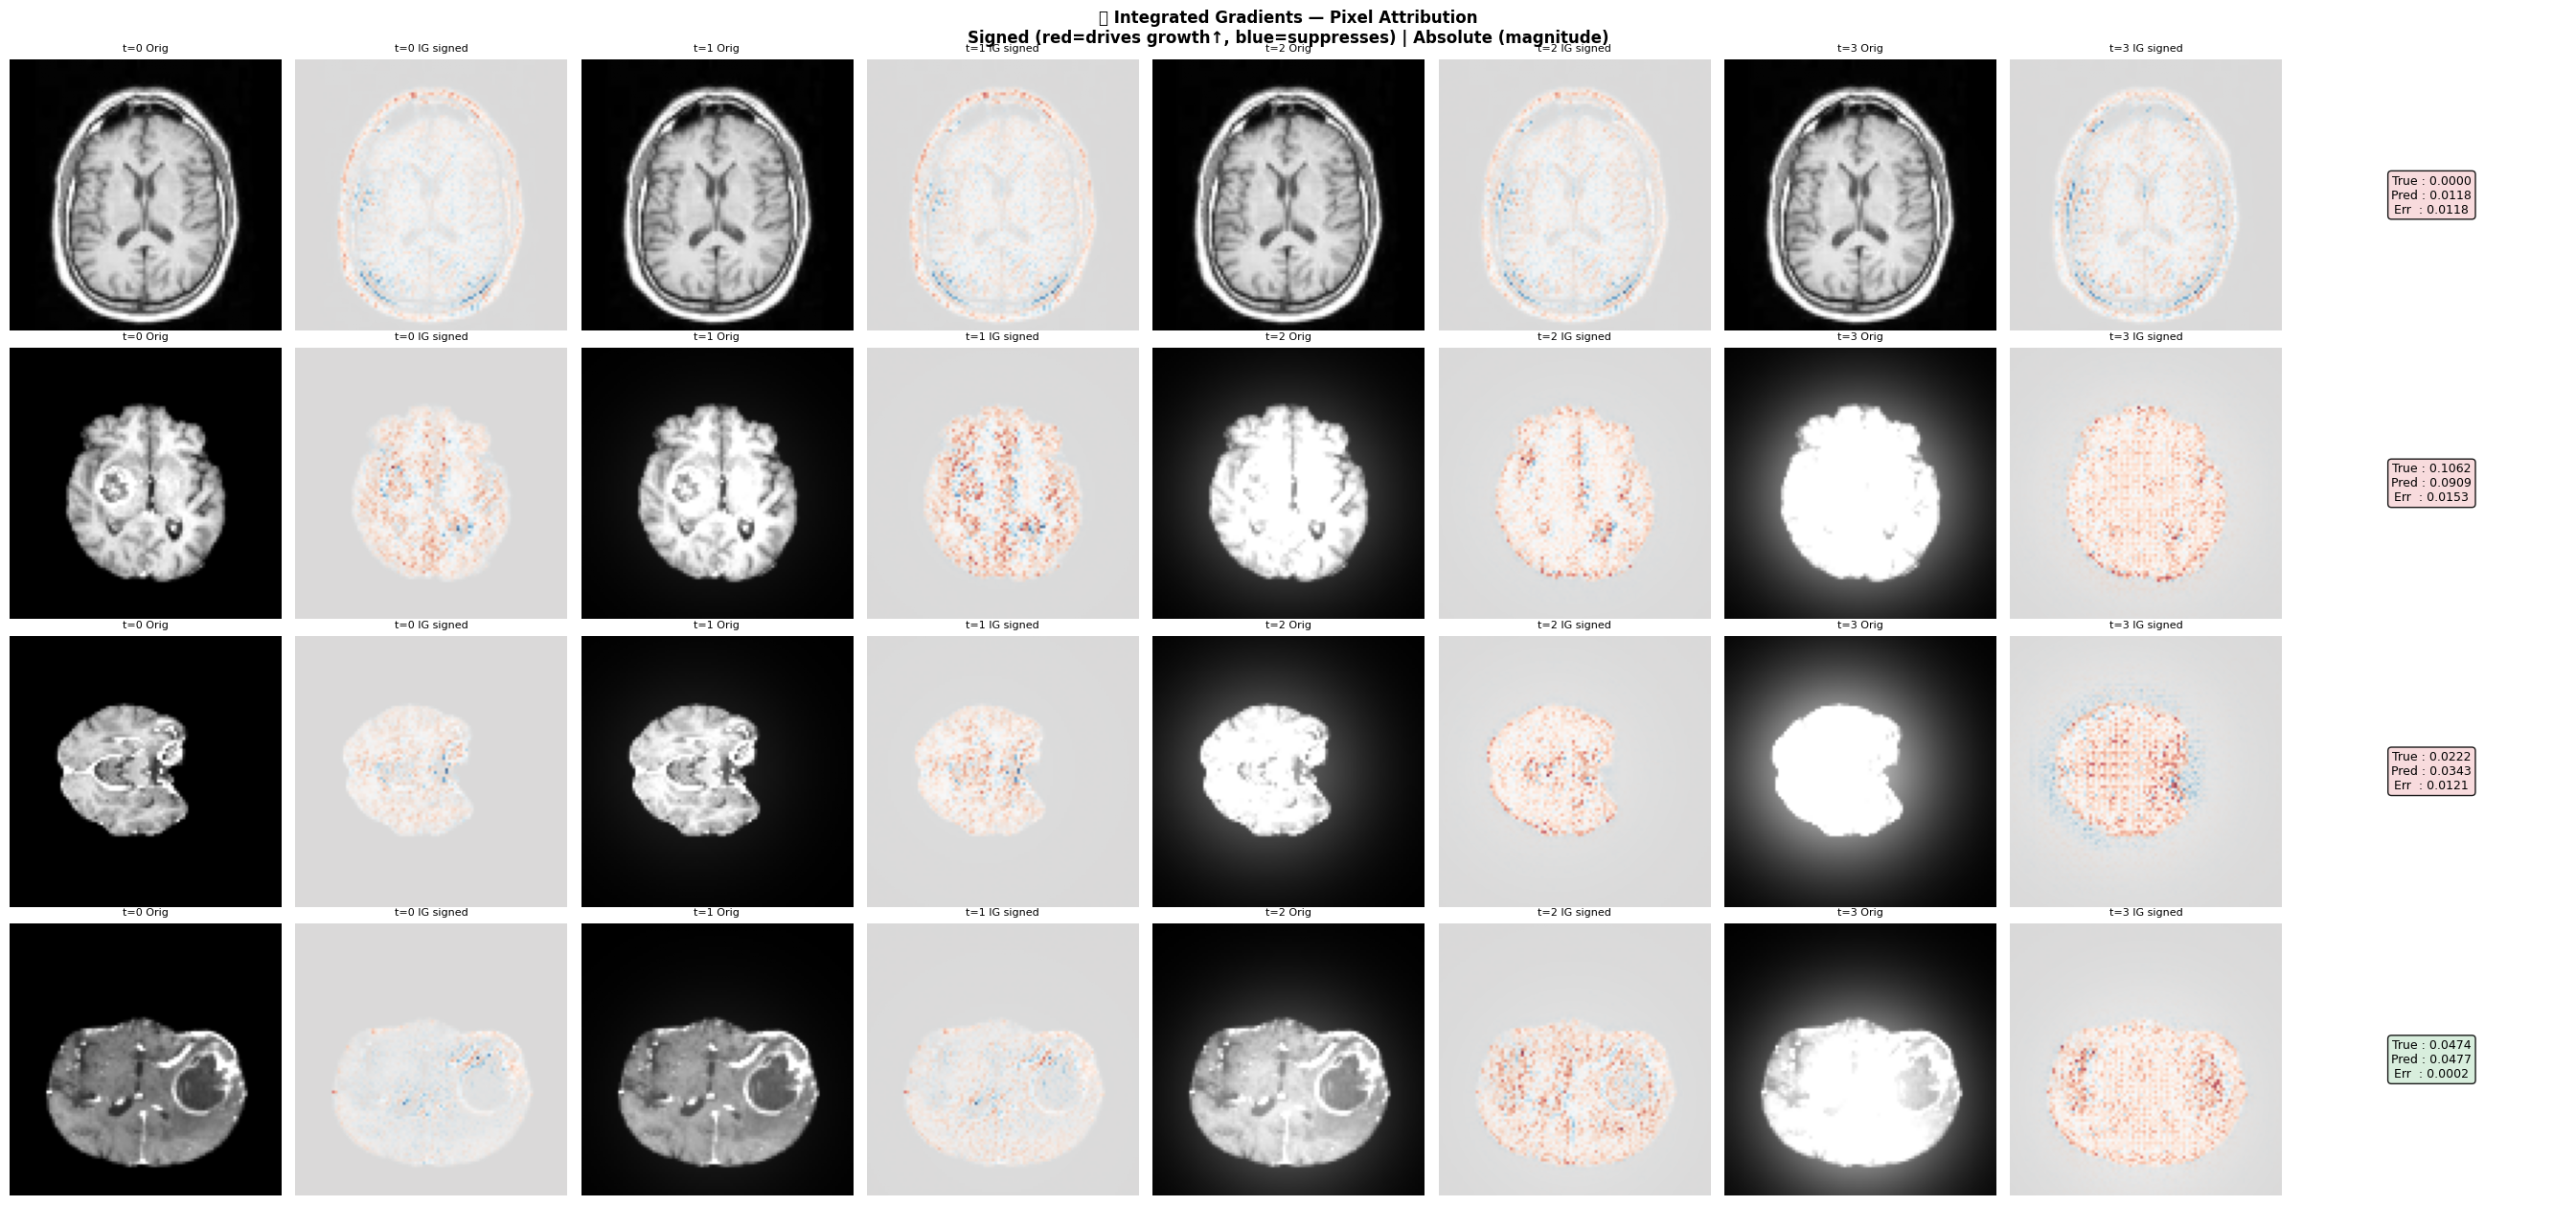

✅ Saved → /kaggle/working/outputs/xai/integrated_gradients.png


IG time evolution:   0%|          | 0/20 [00:00<?, ?it/s]

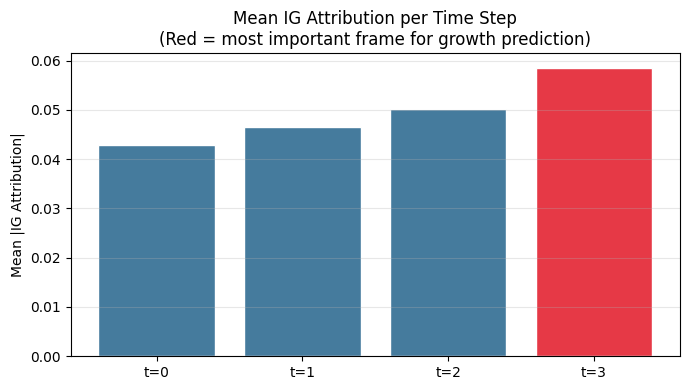

✅ Saved → /kaggle/working/outputs/xai/ig_timestep_importance.png
   Most important time step (IG): t=3


In [20]:
# ═══════════════════════════════════════════════════════
#  CELL 20 — INTEGRATED GRADIENTS VISUALIZATION
#  3 rows: Original | IG signed | IG absolute
# ═══════════════════════════════════════════════════════

N_IG    = 4
ig_idxs = np.random.choice(len(X_test), N_IG, replace=False)

fig, axes = plt.subplots(N_IG, SEQ_LEN*2+1,
                          figsize=(3*(SEQ_LEN*2+1), 3.2*N_IG))
fig.suptitle('🟣 Integrated Gradients — Pixel Attribution\n'
             'Signed (red=drives growth↑, blue=suppresses) | Absolute (magnitude)',
             fontsize=12, fontweight='bold')

for row, idx in enumerate(ig_idxs):
    seq_in = X_test[idx:idx+1]
    tg, pg = float(y_true[idx]), float(y_pred[idx])
    col_offset = 0
    for t in range(SEQ_LEN):
        frame = seq_in[0, t, :, :, 0]
        try:
            ig_map, ig_abs = integrated_gradients(seq_in, model, steps=50, time_step=t)
            # Original
            axes[row, col_offset].imshow(frame, cmap='gray', vmin=0, vmax=1)
            axes[row, col_offset].set_title(f't={t} Orig', fontsize=8)
            # Signed IG overlay
            vmax = max(abs(ig_map.max()), abs(ig_map.min()), 1e-8)
            axes[row, col_offset+1].imshow(frame, cmap='gray', alpha=0.4)
            axes[row, col_offset+1].imshow(ig_map, cmap='RdBu_r',
                                            vmin=-vmax, vmax=vmax, alpha=0.7)
            axes[row, col_offset+1].set_title(f't={t} IG signed', fontsize=8)
        except Exception as e:
            axes[row, col_offset].text(0.5,0.5,'ERR',ha='center',va='center',fontsize=7)
            axes[row, col_offset+1].text(0.5,0.5,'ERR',ha='center',va='center',fontsize=7)
        axes[row, col_offset].axis('off')
        axes[row, col_offset+1].axis('off')
        col_offset += 2
    # Summary
    axes[row, -1].axis('off')
    err = abs(tg-pg)
    col = '#d4edda' if err<0.005 else '#fff3cd' if err<0.01 else '#f8d7da'
    axes[row, -1].text(0.5,0.5,
        f'True : {tg:.4f}\nPred : {pg:.4f}\nErr  : {err:.4f}',
        ha='center',va='center',fontsize=9,
        bbox=dict(boxstyle='round',facecolor=col,alpha=0.9))

plt.tight_layout()
ig_path = os.path.join(XAI_DIR,'integrated_gradients.png')
plt.savefig(ig_path, dpi=150, bbox_inches='tight'); plt.show()
print(f'✅ Saved → {ig_path}')

# ── Mean IG magnitude per time step ──
N_IG_T = min(20, len(X_test))
igt_idxs = np.random.choice(len(X_test), N_IG_T, replace=False)
ig_per_step = []
for idx in tqdm(igt_idxs, desc='IG time evolution'):
    seq_in = X_test[idx:idx+1]
    row_v = []
    for t in range(SEQ_LEN):
        try:
            _, ig_abs = integrated_gradients(seq_in, model, steps=30, time_step=t)
            row_v.append(float(ig_abs.mean()))
        except: row_v.append(0.0)
    ig_per_step.append(row_v)
ig_per_step = np.array(ig_per_step)
avg_ig = ig_per_step.mean(axis=0)

fig, ax = plt.subplots(figsize=(7,4))
ax.bar([f't={t}' for t in range(SEQ_LEN)], avg_ig,
       color=['#457b9d' if v!=avg_ig.max() else '#e63946' for v in avg_ig],
       edgecolor='white')
ax.set_title('Mean IG Attribution per Time Step\n'
             '(Red = most important frame for growth prediction)')
ax.set_ylabel('Mean |IG Attribution|')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
igt_path = os.path.join(XAI_DIR,'ig_timestep_importance.png')
plt.savefig(igt_path, dpi=150); plt.show()
print(f'✅ Saved → {igt_path}')
print(f'   Most important time step (IG): t={int(avg_ig.argmax())}')


In [21]:
# ═══════════════════════════════════════════════════════
#  CELL 21 — OCCLUSION SENSITIVITY
#  Architecture-independent: black-box perturbation
#  Patch occlude করে prediction change measure করা হয়
# ═══════════════════════════════════════════════════════

def occlusion_sensitivity(seq_input, model, time_step=-1,
                           patch_size=12, stride=6):
    """
    Compute occlusion sensitivity map for one time-step frame.

    Slides a patch_size×patch_size occluder across the frame.
    At each position, replaces pixels with mean value and
    measures |prediction change|.

    Args:
        seq_input  : (1, SEQ_LEN, H, W, 1)
        time_step  : which frame to explain
        patch_size : occluder size in pixels
        stride     : step between occluder positions
    Returns:
        sens_map : (H, W) float32 in [0,1] — higher = more sensitive
    """
    t_idx = time_step if time_step >= 0 else SEQ_LEN + time_step
    H, W  = IMG_H, IMG_W

    # Original prediction
    orig_pred = float(model.predict(seq_input, verbose=0)[0, 0])

    # Occlude value = mean of the frame
    occ_val   = float(seq_input[0, t_idx, :, :, 0].mean())

    sens_map  = np.zeros((H, W), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.float32)

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            occluded      = seq_input.copy()
            occluded[0, t_idx, y:y+patch_size, x:x+patch_size, 0] = occ_val
            occ_pred      = float(model.predict(occluded, verbose=0)[0, 0])
            sensitivity   = abs(orig_pred - occ_pred)
            sens_map[y:y+patch_size, x:x+patch_size]   += sensitivity
            count_map[y:y+patch_size, x:x+patch_size]  += 1

    count_map = np.maximum(count_map, 1)
    sens_map  = sens_map / count_map
    sens_map  = sens_map / (sens_map.max() + 1e-8)
    return sens_map.astype(np.float32)


# ── Smoke test (fast: patch_size=24, stride=12) ──
print('Occlusion smoke test (fast settings)...')
_sm = occlusion_sensitivity(X_test[:1], model, time_step=0,
                             patch_size=24, stride=12)
print(f'✅ Occlusion OK — shape {_sm.shape}  range [{_sm.min():.3f},{_sm.max():.3f}]')


Occlusion smoke test (fast settings)...
✅ Occlusion OK — shape (96, 96)  range [0.028,1.000]


  Sample 1 t=0... OK
  Sample 1 t=1... OK
  Sample 1 t=2... OK
  Sample 1 t=3... OK
  Sample 2 t=0... OK
  Sample 2 t=1... OK
  Sample 2 t=2... OK
  Sample 2 t=3... OK
  Sample 3 t=0... OK
  Sample 3 t=1... OK
  Sample 3 t=2... OK
  Sample 3 t=3... OK


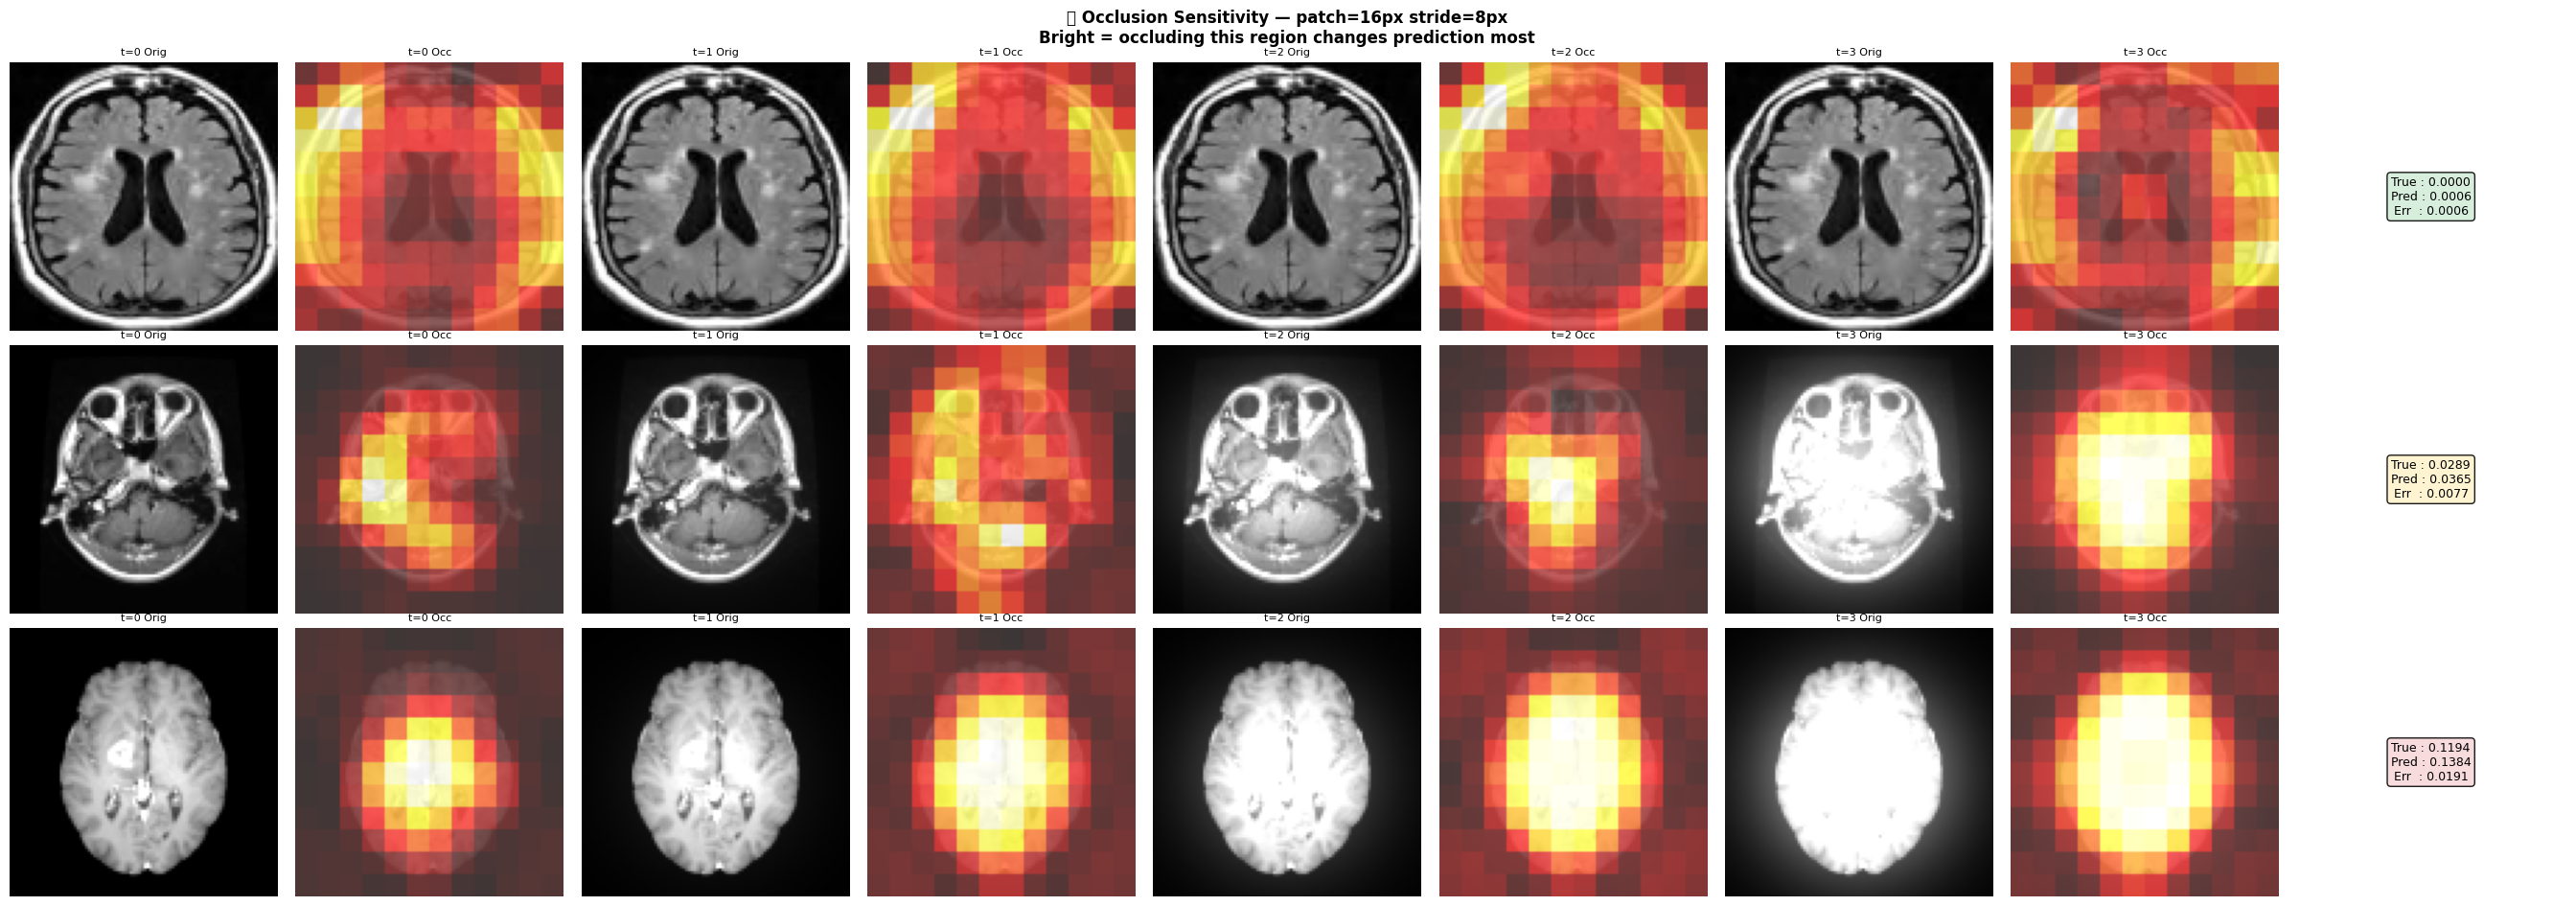


✅ Saved → /kaggle/working/outputs/xai/occlusion_sensitivity.png


In [22]:
# ═══════════════════════════════════════════════════════
#  CELL 22 — OCCLUSION SENSITIVITY VISUALIZATION
#  Note: slow — ~(H/stride)×(W/stride) forward passes per frame
#  patch_size=16, stride=8 → ~100 passes per frame, reasonable on GPU
# ═══════════════════════════════════════════════════════

PATCH_SIZE = 16
STRIDE     = 8
N_OCC      = 3    # fewer samples — each takes longer than Grad-CAM
occ_idxs   = np.random.choice(len(X_test), N_OCC, replace=False)

fig, axes = plt.subplots(N_OCC, SEQ_LEN*2+1,
                          figsize=(3*(SEQ_LEN*2+1), 3.2*N_OCC))
fig.suptitle(f'🟢 Occlusion Sensitivity — patch={PATCH_SIZE}px stride={STRIDE}px\n'
             'Bright = occluding this region changes prediction most',
             fontsize=12, fontweight='bold')

for row, idx in enumerate(occ_idxs):
    seq_in = X_test[idx:idx+1]
    tg, pg = float(y_true[idx]), float(y_pred[idx])
    col_offset = 0
    for t in range(SEQ_LEN):
        frame = seq_in[0, t, :, :, 0]
        print(f'  Sample {row+1} t={t}...', end=' ', flush=True)
        try:
            sm = occlusion_sensitivity(seq_in, model, time_step=t,
                                        patch_size=PATCH_SIZE, stride=STRIDE)
            # Original
            axes[row, col_offset].imshow(frame, cmap='gray', vmin=0, vmax=1)
            axes[row, col_offset].set_title(f't={t} Orig', fontsize=8)
            # Occlusion map overlay
            axes[row, col_offset+1].imshow(frame, cmap='gray', alpha=0.4)
            axes[row, col_offset+1].imshow(sm, cmap='hot', vmin=0, vmax=1, alpha=0.65)
            axes[row, col_offset+1].set_title(f't={t} Occ', fontsize=8)
            print('OK')
        except Exception as e:
            axes[row, col_offset].text(0.5,0.5,'ERR',ha='center',va='center',fontsize=7)
            axes[row, col_offset+1].text(0.5,0.5,'ERR',ha='center',va='center',fontsize=7)
            print(f'FAIL: {e}')
        axes[row, col_offset].axis('off')
        axes[row, col_offset+1].axis('off')
        col_offset += 2
    axes[row,-1].axis('off')
    err = abs(tg-pg)
    col = '#d4edda' if err<0.005 else '#fff3cd' if err<0.01 else '#f8d7da'
    axes[row,-1].text(0.5,0.5,
        f'True : {tg:.4f}\nPred : {pg:.4f}\nErr  : {err:.4f}',
        ha='center',va='center',fontsize=9,
        bbox=dict(boxstyle='round',facecolor=col,alpha=0.9))

plt.tight_layout()
occ_path = os.path.join(XAI_DIR,'occlusion_sensitivity.png')
plt.savefig(occ_path, dpi=150, bbox_inches='tight'); plt.show()
print(f'\n✅ Saved → {occ_path}')


Explaining sample #96 — True=0.0000  Pred=0.1331
Computing Grad-CAM... OK
Computing Integrated Gradients... OK
Computing Occlusion... OK


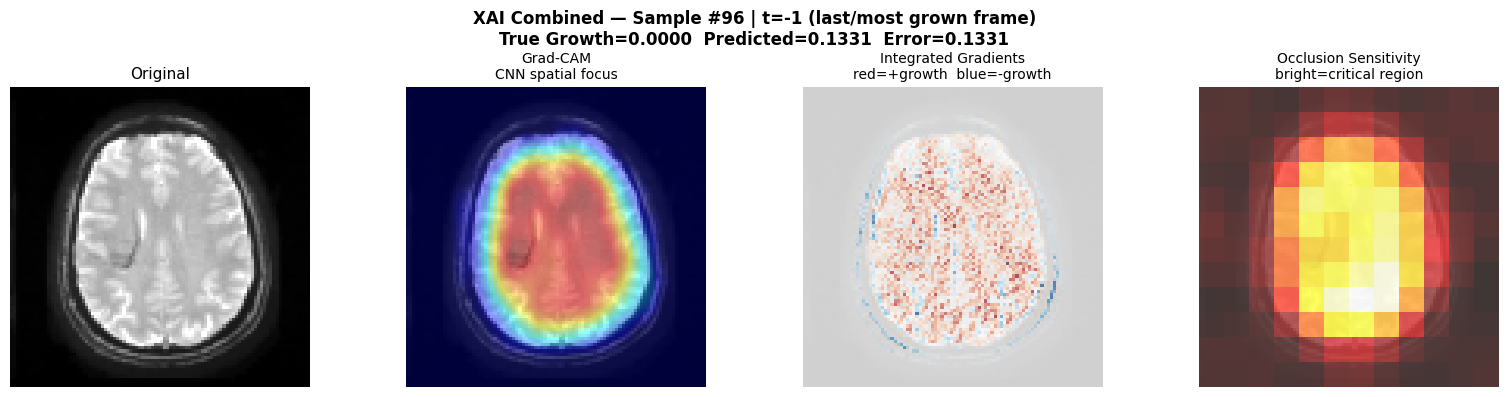

✅ Saved → /kaggle/working/outputs/xai/xai_combined_summary.png


In [23]:
# ═══════════════════════════════════════════════════════
#  CELL 23 — XAI COMBINED SUMMARY
#  One sample: Original | Grad-CAM | IG | Occlusion
#  All 3 methods side-by-side for last time step (most grown)
# ═══════════════════════════════════════════════════════

summ_idx = int(np.argmax(np.abs(y_pred - y_true)))  # most interesting prediction
seq_in   = X_test[summ_idx:summ_idx+1]
tg, pg   = float(y_true[summ_idx]), float(y_pred[summ_idx])
frame    = seq_in[0, -1, :, :, 0]  # last time step

print(f'Explaining sample #{summ_idx} — True={tg:.4f}  Pred={pg:.4f}')

# Compute all 3
print('Computing Grad-CAM...', end=' ', flush=True)
hm = make_gradcam_heatmap(seq_in, model, time_step=-1)
gc_overlay = overlay_gradcam(frame, hm)
print('OK')

print('Computing Integrated Gradients...', end=' ', flush=True)
ig_map, _ = integrated_gradients(seq_in, model, steps=50, time_step=-1)
vmax_ig = max(abs(ig_map.max()), abs(ig_map.min()), 1e-8)
print('OK')

print('Computing Occlusion...', end=' ', flush=True)
sm = occlusion_sensitivity(seq_in, model, time_step=-1,
                            patch_size=PATCH_SIZE, stride=STRIDE)
print('OK')

# Plot
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(
    f'XAI Combined — Sample #{summ_idx} | t=-1 (last/most grown frame)\n'
    f'True Growth={tg:.4f}  Predicted={pg:.4f}  Error={abs(tg-pg):.4f}',
    fontsize=12, fontweight='bold'
)

axes[0].imshow(frame, cmap='gray'); axes[0].set_title('Original', fontsize=11)
axes[0].axis('off')

axes[1].imshow(gc_overlay); axes[1].set_title('Grad-CAM\nCNN spatial focus', fontsize=10)
axes[1].axis('off')

axes[2].imshow(frame, cmap='gray', alpha=0.45)
axes[2].imshow(ig_map, cmap='RdBu_r', vmin=-vmax_ig, vmax=vmax_ig, alpha=0.65)
axes[2].set_title('Integrated Gradients\nred=+growth  blue=-growth', fontsize=10)
axes[2].axis('off')

axes[3].imshow(frame, cmap='gray', alpha=0.4)
axes[3].imshow(sm, cmap='hot', vmin=0, vmax=1, alpha=0.65)
axes[3].set_title('Occlusion Sensitivity\nbright=critical region', fontsize=10)
axes[3].axis('off')

plt.tight_layout()
comb_path = os.path.join(XAI_DIR, 'xai_combined_summary.png')
plt.savefig(comb_path, dpi=150, bbox_inches='tight'); plt.show()
print(f'✅ Saved → {comb_path}')


In [24]:
# ═══════════════════════════════════════════════════════
#  CELL 24 — XAI FILE LISTING
# ═══════════════════════════════════════════════════════

print('\n📦 XAI outputs:')
for f in sorted(os.listdir(XAI_DIR)):
    fpath = os.path.join(XAI_DIR, f)
    kb    = os.path.getsize(fpath) / 1024
    print(f'   {f:50s}  {kb:8.1f} KB')

print('\n' + '='*65)
print('  XAI Summary — ProgNet v8')
print('='*65)
print('  🟠 Grad-CAM')
print('     gradcam_heatmaps.png          → CNN focus per frame × sample')
print('     gradcam_time_evolution.png    → Attention shift over time')
print('  🟣 Integrated Gradients')
print('     integrated_gradients.png      → Signed pixel attribution')
print('     ig_timestep_importance.png    → Most important time step (IG)')
print('  🟢 Occlusion Sensitivity')
print('     occlusion_sensitivity.png     → Critical regions (black-box)')
print('  🔀 Combined')
print('     xai_combined_summary.png      → All 3 methods side-by-side')
print('='*65)
print(f'\n  Grad-CAM  most attended:  t={int(avg_int.argmax())}')
print(f'  IG        most important:  t={int(avg_ig.argmax())}')



📦 XAI outputs:
   gradcam_heatmaps.png                                   451.4 KB
   gradcam_time_evolution.png                              62.1 KB
   ig_timestep_importance.png                              35.5 KB
   integrated_gradients.png                               591.6 KB
   occlusion_sensitivity.png                              407.0 KB
   xai_combined_summary.png                               128.2 KB

  XAI Summary — ProgNet v8
  🟠 Grad-CAM
     gradcam_heatmaps.png          → CNN focus per frame × sample
     gradcam_time_evolution.png    → Attention shift over time
  🟣 Integrated Gradients
     integrated_gradients.png      → Signed pixel attribution
     ig_timestep_importance.png    → Most important time step (IG)
  🟢 Occlusion Sensitivity
     occlusion_sensitivity.png     → Critical regions (black-box)
  🔀 Combined
     xai_combined_summary.png      → All 3 methods side-by-side

  Grad-CAM  most attended:  t=0
  IG        most important:  t=3
